In [1]:
#| echo: false

# This cell will not be rendered but is to hide warnings

import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger('statsforecast').setLevel(logging.ERROR)

import pandas as pd
pd.set_option('display.max_rows', 6)
pd.set_option("display.float_format", "{:.2f}".format)

# Conformal Seasonal Pool (CSP)

> Step-by-step guide on using the `ConformalSeasonalPool` model in `StatsForecast`.

The Conformal Seasonal Pool (CSP) is a **training-free probabilistic forecaster** introduced in
[Manokhin (2026), *Training-Free Probabilistic Time-Series Forecasting with Conformal Seasonal Pools*](https://arxiv.org/abs/2605.03789).
It produces a seasonal naive point forecast with **empirically well-calibrated prediction intervals**. It does this without estimating a single parameter, as the predictive distribution is built entirely from empirical draws of the training history.

In the paper's benchmark, CSP matches or beats deep probabilistic baselines such as DeepNPTS on CRPS while keeping empirical coverage close to the nominal level. It also runs **orders of magnitude faster** (seconds instead of hours) because there is nothing to train.

In this notebook, we walk through the model on the [UCI ElectricityLoadDiagrams20112014 dataset](https://archive.ics.uci.edu/dataset/321/electricityloaddiagrams20112014), the raw source of the electricity benchmark used in the paper, and mirrors the paper's rolling-origin evaluation protocol to confirm that the intervals are calibrated.

## How the model works

The point forecast is exactly a [Seasonal Naive](../../src/core/models.html#seasonalnaive) forecast $\mu_h$, which is the value observed one seasonal period ago. All of the model's machinery goes into the **predictive distribution around** $\mu_h$. The distribution is estimated from `n_samples` draws of a two-component mixture.

1. **Seasonal pool.** Historical observations at the *same seasonal phase* as the forecast target (e.g., all past 3 PM values when forecasting 3 PM), sampled with exponentially decaying weights $\propto e^{-\lambda \cdot \text{age}}$ so that newer observations are drawn more often (`decay` = $\lambda$).
2. **Calibration residuals.** Signed seasonal naive errors $r_t = y_t - y_{t-m}$ computed on the most recent `calib_frac` fraction of the history and added back to the point forecast as $\mu_h + r$.

Each sample comes from the seasonal pool with probability $w$ and from the residual component with probability $1-w$. The `variant` parameter controls $w$.

- `"fixed"` (**CSP-Fixed**) uses $w = 0.5$ always.
- `"adaptive"` (**CSP-Adaptive**) uses $w = 0$ when there is no seasonality (`season_length` ≤ 1), $w = 0.3$ when the seasonal pool is thin (fewer than 3 same-phase observations), and $w = 0.5$ otherwise.

Prediction intervals are empirical quantiles of the samples with a **finite-sample conformal correction**. The lower cut uses $\lfloor(n+1)q\rfloor/n$ and the upper cut uses $\lceil(n+1)q\rceil/n$, which orients the quantile estimates conservatively and helps keep empirical coverage close to the nominal level, even with a modest sample budget.

**Hyperparameters**

| Parameter | Default | Meaning |
|---|---|---|
| `season_length` | Required | Observations per seasonal cycle (24 for hourly data with a daily cycle). |
| `n_samples` | 100 | Mixture samples used to estimate the intervals. A level-$L$ interval needs at least $\lceil 2/(1-L/100)\rceil - 1$ samples (≥ 39 for 95%). |
| `variant` | `"adaptive"` | `"adaptive"` or `"fixed"` mixture weight (see above). |
| `calib_frac` | 0.5 | Fraction of the most recent history used for the calibration residual pool. |
| `decay` | 0.01 | Exponential recency rate for the seasonal pool weights. |

**When to use CSP?** 

Strongly seasonal series where you need calibrated prediction intervals at essentially zero computational cost, for example as a probabilistic baseline before reaching for heavier models, or in large-scale settings where per-series training is too expensive.

## Loading libraries and data

:::{.callout-tip}
You need StatsForecast to run this notebook. To install it, follow these [instructions](../getting-started/installation.html).
:::

In [2]:
import numpy as np
import pandas as pd

from statsforecast import StatsForecast
from statsforecast.models import ConformalSeasonalPool, SeasonalNaive

### Download the electricity dataset

We use the [ElectricityLoadDiagrams20112014](https://archive.ics.uci.edu/dataset/321/electricityloaddiagrams20112014) dataset from the UCI Machine Learning Repository, which contains the electricity consumption (kW) of 370 Portuguese clients, recorded every 15 minutes from 2011 to 2014. This is the raw source behind the hourly `electricity` benchmark on which the CSP paper is evaluated.

:::{.callout-warning}
The zip file is about 250 MB. The cell below caches it locally, so it is only downloaded once.
:::

In [3]:
import zipfile
from pathlib import Path
from urllib.request import urlretrieve

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
DATA_URL = "https://archive.ics.uci.edu/static/public/321/electricityloaddiagrams20112014.zip"
zip_path = DATA_DIR / "electricityloaddiagrams20112014.zip"
txt_path = DATA_DIR / "LD2011_2014.txt"

if not txt_path.exists():
    if not zip_path.exists():
        urlretrieve(DATA_URL, zip_path)
    with zipfile.ZipFile(zip_path) as f:
        f.extract("LD2011_2014.txt", DATA_DIR)

The file is semicolon-separated with decimal commas. Each timestamp marks the end of a 15-minute interval, so we aggregate to hourly totals (the convention used by the GluonTS `electricity` benchmark). To keep the notebook fast we work with ten clients over the last three months of 2014, keeping only clients that are active (non-zero) throughout the window, since some clients joined after 2011 and their earlier readings are recorded as zero.

In [4]:
raw = pd.read_csv(txt_path, sep=";", decimal=",", index_col=0, parse_dates=True)
hourly = raw.resample("h").sum()

window = hourly.loc["2014-10-01":"2014-12-31"]
active_clients = window.columns[(window > 0).all()]
clients = list(active_clients[:10])

df = (
    window[clients]
    .reset_index(names="ds")
    .melt(id_vars="ds", var_name="unique_id", value_name="y")
)
df

,ds,unique_id,y
0,2014-10-01 00:00:00,MT_002,92.46
1,2014-10-01 01:00:00,MT_002,79.66
2,2014-10-01 02:00:00,MT_002,77.52
...,...,...,...
22077,2014-12-31 21:00:00,MT_012,727.66
22078,2014-12-31 22:00:00,MT_012,691.49
22079,2014-12-31 23:00:00,MT_012,665.96


### Explore the data

The hourly load shows the strong daily seasonality that CSP exploits.

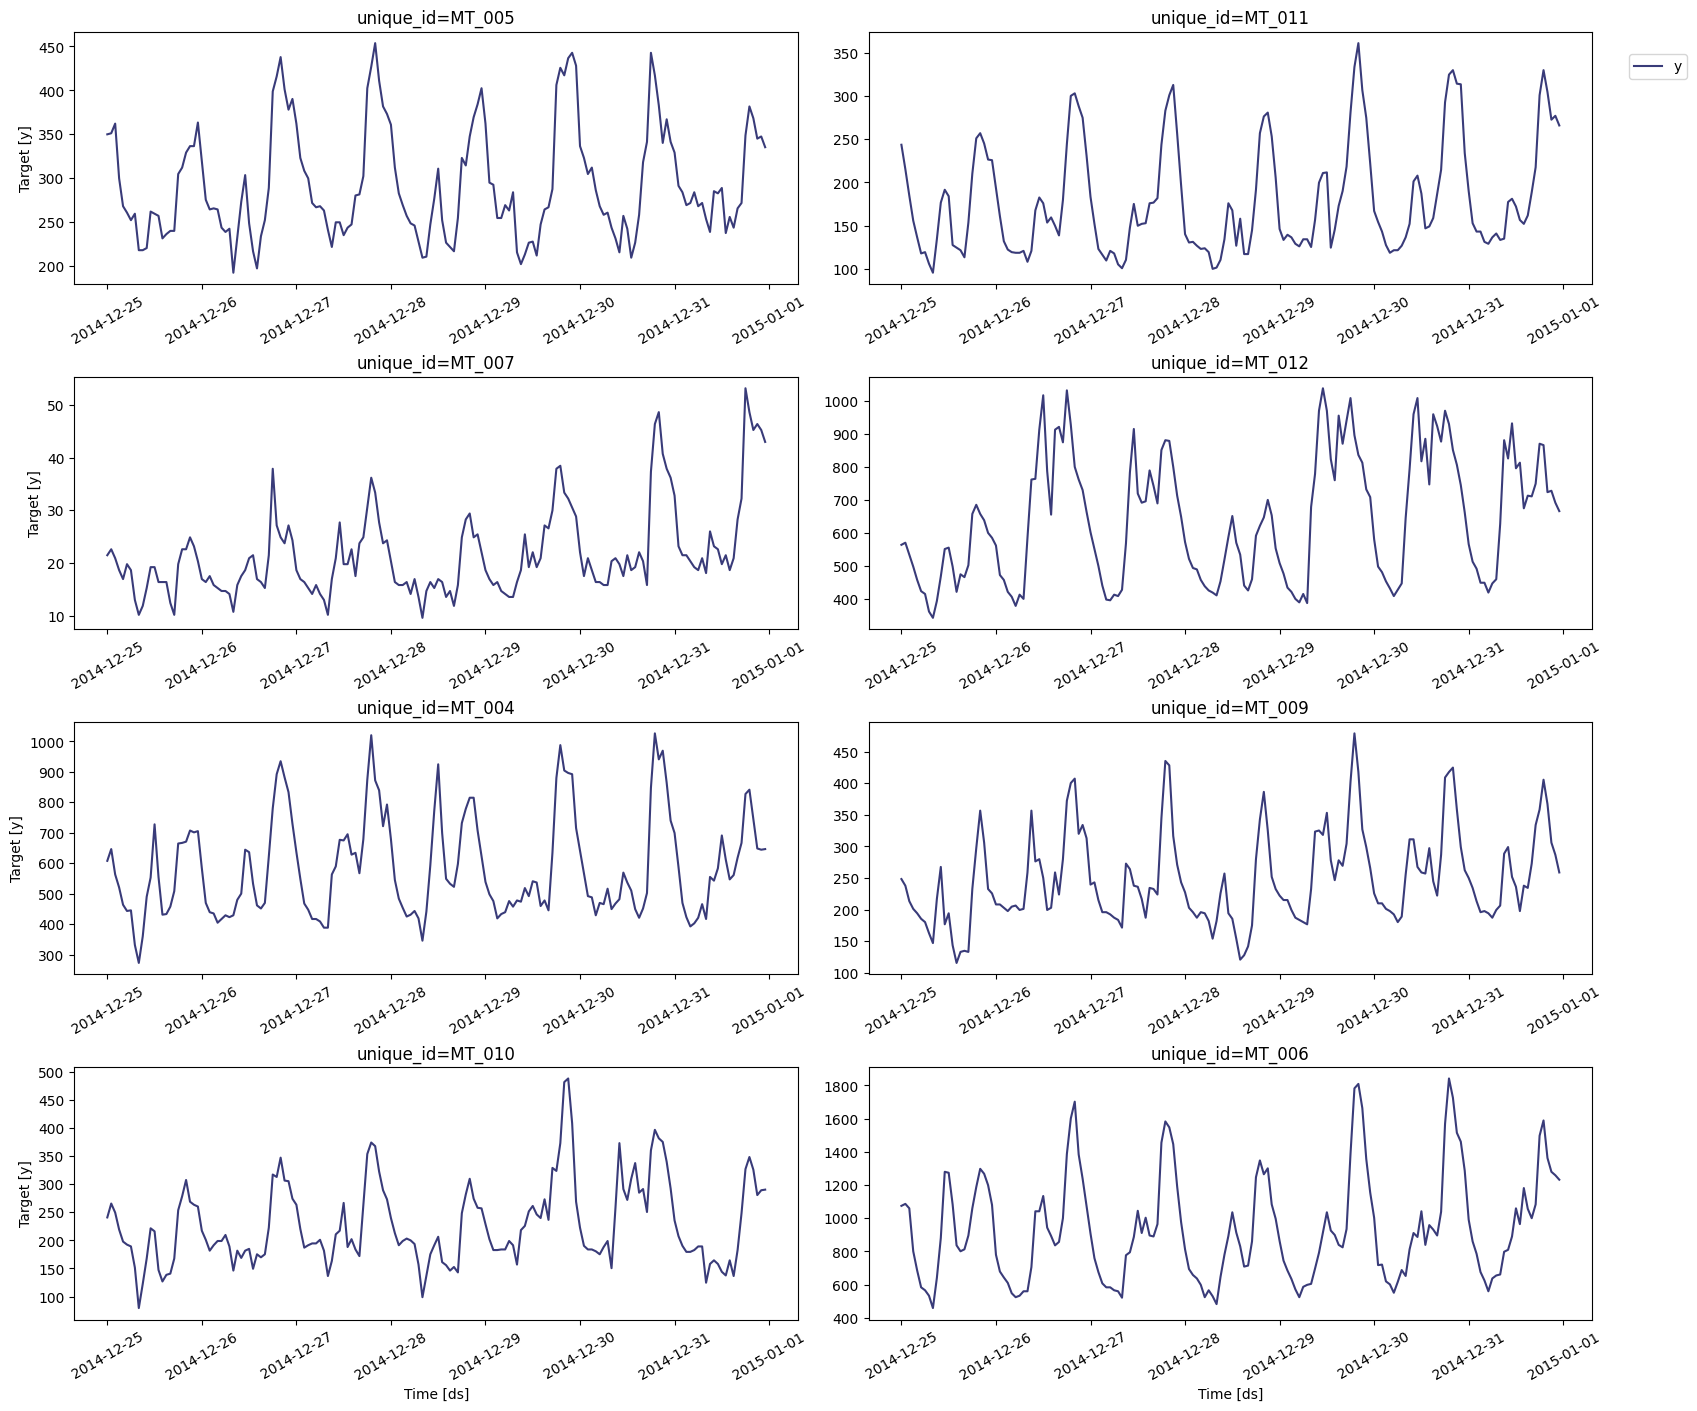

In [5]:
StatsForecast.plot(df, max_insample_length=24 * 7)

## Forecasting with prediction intervals

We instantiate `ConformalSeasonalPool` alongside `SeasonalNaive` and forecast the next day (`h=24`) with 80% and 95% prediction intervals. The default `n_samples=100` comfortably exceeds the minimum number of samples required for non-degenerate 80% and 95% intervals. Note that CSP requires no training, so `forecast` returns almost instantly.

In [6]:
season_length = 24  # daily seasonality for hourly data
horizon = 24        # forecast one day ahead, as in the paper

sf = StatsForecast(
    models=[
        ConformalSeasonalPool(season_length=season_length),
        SeasonalNaive(season_length=season_length),
    ],
    freq="h",
)

fcst = sf.forecast(df=df, h=horizon, level=[80, 95])
fcst

,unique_id,ds,CSP-Adaptive,CSP-Adaptive-lo-95,CSP-Adaptive-lo-80,CSP-Adaptive-hi-80,CSP-Adaptive-hi-95,SeasonalNaive,SeasonalNaive-lo-80,SeasonalNaive-lo-95,SeasonalNaive-hi-80,SeasonalNaive-hi-95
0,MT_002,2015-01-01 00:00:00,78.95,65.38,75.32,81.79,94.02,78.95,69.05,63.81,88.85,94.09
1,MT_002,2015-01-01 01:00:00,73.26,60.46,68.85,79.79,83.94,73.26,63.36,58.12,83.16,88.40
2,MT_002,2015-01-01 02:00:00,68.99,58.29,66.07,75.39,91.04,68.99,59.09,53.85,78.89,84.13
...,...,...,...,...,...,...,...,...,...,...,...,...
237,MT_012,2015-01-01 21:00:00,727.66,569.32,637.23,812.77,936.60,727.66,589.71,516.69,865.61,938.63
238,MT_012,2015-01-01 22:00:00,691.49,482.98,595.53,783.36,951.49,691.49,553.54,480.52,829.44,902.46
239,MT_012,2015-01-01 23:00:00,665.96,435.57,553.19,721.66,910.26,665.96,528.01,454.99,803.90,876.93


The point forecast of CSP is *exactly* the seasonal naive forecast, and the value the model adds is the calibrated intervals around it:

In [7]:
np.allclose(fcst["CSP-Adaptive"], fcst["SeasonalNaive"])

True

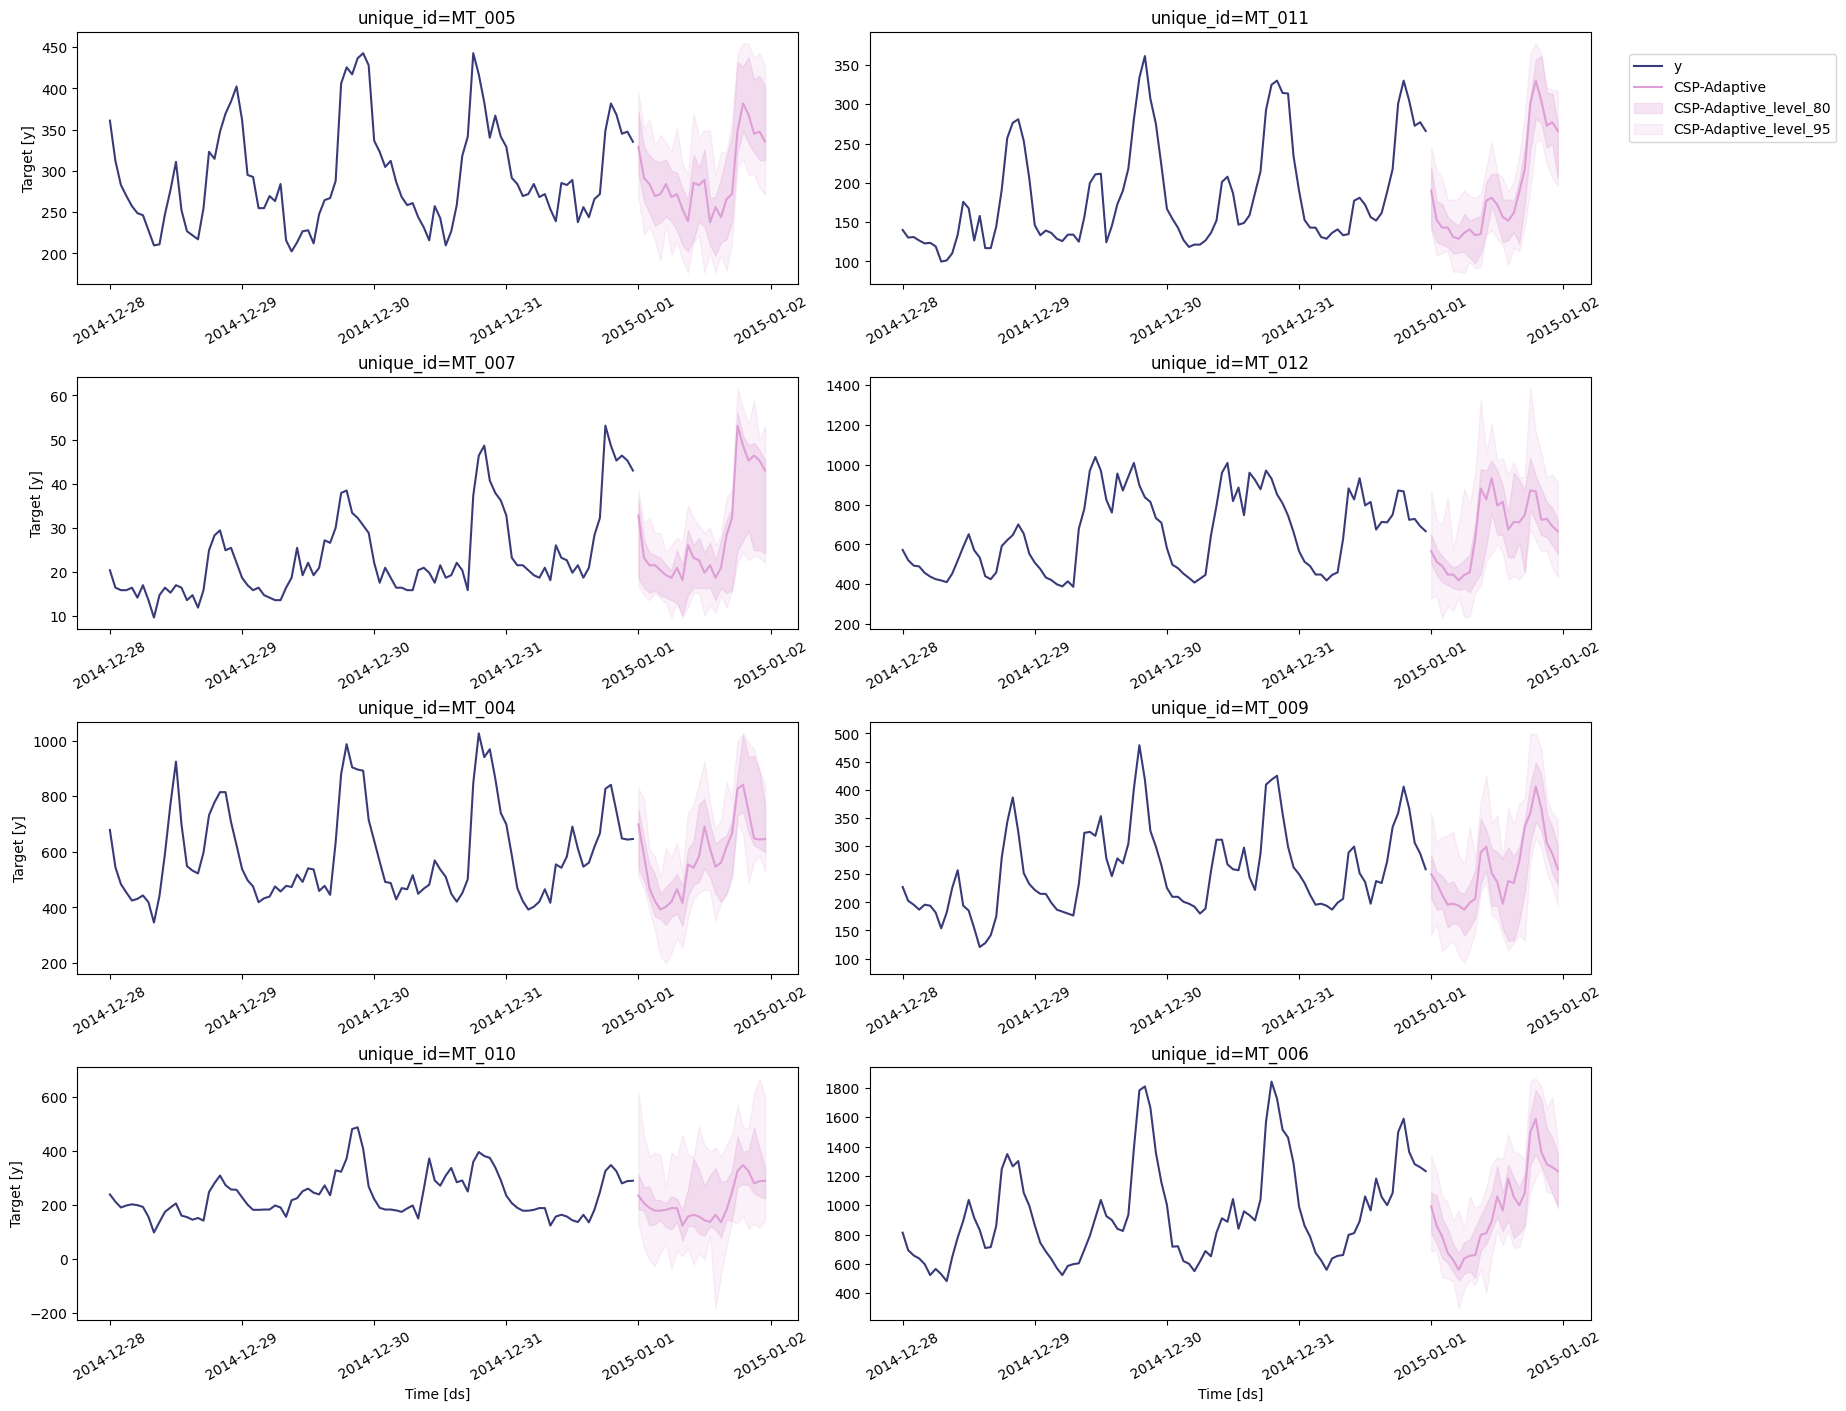

In [8]:
sf.plot(df, fcst, level=[80, 95], max_insample_length=24 * 4, models=["CSP-Adaptive"])

## Evaluating calibration with the paper's protocol

The paper evaluates each method with a **rolling-origin protocol** using 7 non-overlapping evaluation windows per series, each one day long (`h=24`). `StatsForecast.cross_validation` implements exactly this. We request the levels `[20, 40, 60, 80]`, whose interval bounds correspond to the quantile grid $q \in \{0.1, 0.2, \ldots, 0.9\}$ used by the paper's CRPS and quantile-loss metrics, plus level 95 for the coverage check.

In [9]:
%%time
cv_df = sf.cross_validation(
    df=df,
    h=horizon,
    n_windows=7,
    step_size=horizon,
    level=[20, 40, 60, 80, 95],
)
cv_df

CPU times: user 116 ms, sys: 4.05 ms, total: 120 ms
Wall time: 122 ms


,unique_id,ds,cutoff,y,CSP-Adaptive,CSP-Adaptive-lo-95,CSP-Adaptive-lo-80,CSP-Adaptive-lo-60,CSP-Adaptive-lo-40,CSP-Adaptive-lo-20,...,SeasonalNaive-lo-20,SeasonalNaive-lo-40,SeasonalNaive-lo-60,SeasonalNaive-lo-80,SeasonalNaive-lo-95,SeasonalNaive-hi-20,SeasonalNaive-hi-40,SeasonalNaive-hi-60,SeasonalNaive-hi-80,SeasonalNaive-hi-95
0,MT_002,2014-12-25 00:00:00,2014-12-24 23:00:00,79.66,81.79,72.50,75.39,76.81,76.81,77.95,...,79.83,77.74,75.28,71.88,66.63,83.75,85.85,88.30,91.70,96.95
1,MT_002,2014-12-25 01:00:00,2014-12-24 23:00:00,81.08,72.55,66.09,68.28,69.70,69.70,71.12,...,70.59,68.49,66.04,62.63,57.39,74.51,76.60,79.06,82.46,87.70
2,MT_002,2014-12-25 02:00:00,2014-12-24 23:00:00,76.10,68.28,55.85,62.59,66.86,66.86,66.86,...,66.32,64.22,61.77,58.37,53.12,70.24,72.33,74.79,78.19,83.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,MT_012,2014-12-31 21:00:00,2014-12-30 23:00:00,727.66,806.38,597.53,634.47,696.60,761.70,768.09,...,779.07,749.86,715.66,668.24,595.11,833.69,862.91,897.11,944.53,1017.66
1678,MT_012,2014-12-31 22:00:00,2014-12-30 23:00:00,691.49,744.68,550.21,616.17,653.19,666.17,716.17,...,717.37,688.15,653.96,606.54,533.41,771.99,801.21,835.40,882.83,955.96
1679,MT_012,2014-12-31 23:00:00,2014-12-30 23:00:00,665.96,661.70,468.09,553.19,592.77,608.51,640.85,...,634.39,605.17,570.98,523.56,450.43,689.01,718.23,752.43,799.85,872.98


Note the wall-clock time above. The full 7-window evaluation of both models over ten series runs in about a second on CPU, matching the training-free speed the paper reports, while its deep baseline needs hours for the same protocol.

We now compute the paper's metrics with [utilsforecast](https://nixtlaverse.nixtla.io/utilsforecast).

- **Scaled CRPS** and **mean quantile loss** over $q \in \{0.1, \ldots, 0.9\}$ are the headline distributional accuracy metrics.

- **Empirical 95% coverage** is the fraction of observations inside the 95% interval, which should be close to 0.95 for a calibrated model.

- **Mean 95% interval width** measures the sharpness of the intervals.

In [10]:
import utilsforecast.losses as ufl
from utilsforecast.evaluation import evaluate

accuracy = evaluate(
    cv_df,
    metrics=[ufl.scaled_crps, ufl.mqloss],
    level=[20, 40, 60, 80],
    agg_fn="mean",
)
accuracy.groupby("metric")[["CSP-Adaptive", "SeasonalNaive"]].mean()

,CSP-Adaptive,SeasonalNaive
metric,,
mqloss,22.66,28.77
scaled_crps,0.10,0.13


In [11]:
coverage = evaluate(cv_df, metrics=[ufl.coverage], level=[95], agg_fn="mean")
summary = coverage.groupby("metric")[["CSP-Adaptive", "SeasonalNaive"]].mean()
summary.loc["mean 95% interval width"] = [
    (cv_df[f"{m}-hi-95"] - cv_df[f"{m}-lo-95"]).mean()
    for m in ["CSP-Adaptive", "SeasonalNaive"]
]
summary

,CSP-Adaptive,SeasonalNaive
metric,,
coverage_level95,0.93,0.84
mean 95% interval width,306.75,257.12


The results mirror the paper's findings:

**CSP's empirical 95% coverage is close to the nominal level** (the paper reports a mean of 0.89 across its six datasets), while the parametric Gaussian intervals of `SeasonalNaive` undercover noticeably.

All of this comes from a model with **zero trained parameters** that evaluates in a fraction of a second.

## Fixed vs. adaptive variant

With `variant="fixed"`, the mixture weight is always $w=0.5$. The adaptive variant only deviates from this when seasonality is absent (`season_length` ≤ 1) or the seasonal pool is thin. On a series this long, the two variants behave identically. To see the adaptive rule act, we now forecast from a **short history** of two and a half days. Each hour of the day has been observed at most 3 times, and the adaptive rule shrinks the seasonal pool's weight to 0.3, leaning more on the calibration residuals.

In [12]:
short_series = df.query("unique_id == 'MT_002'").tail(60)  # 2.5 days of history

sf_variants = StatsForecast(
    models=[
        ConformalSeasonalPool(season_length=season_length, variant="adaptive"),
        ConformalSeasonalPool(season_length=season_length, variant="fixed"),
    ],
    freq="h",
)
fcst_short = sf_variants.forecast(df=short_series, h=horizon, level=[95])

pd.DataFrame({
    "mean 95% width": [
        (fcst_short[f"{m}-hi-95"] - fcst_short[f"{m}-lo-95"]).mean()
        for m in ["CSP-Adaptive", "CSP-Fixed"]
    ]
}, index=["CSP-Adaptive", "CSP-Fixed"])

,mean 95% width
CSP-Adaptive,31.06
CSP-Fixed,29.96


On this well-behaved series, the resulting widths are similar because the two sampling pools happen to agree. The adaptive safeguard matters when they don't. With only a couple of same-season observations, a single outlier in the seasonal pool can distort the intervals, and down-weighting the pool keeps them stable. If in doubt, keep the default `variant="adaptive"`, as it reduces to the fixed rule whenever the history is rich enough.

## References

- [Valery Manokhin (2026). "Training-Free Probabilistic Time-Series Forecasting with Conformal Seasonal Pools".](https://arxiv.org/abs/2605.03789)
- [`ConformalSeasonalPool` API reference.](../../src/core/models.html#conformalseasonalpool)
- [`SeasonalNaive` API reference.](../../src/core/models.html#seasonalnaive)
- [Conformal prediction intervals for any StatsForecast model.](../tutorials/conformalprediction.html) CSP is *natively* conformal. For models that are not, the `ConformalIntervals` wrapper described in that tutorial adds conformal intervals on top.
- [Trindade, Artur (2015). "ElectricityLoadDiagrams20112014". UCI Machine Learning Repository.](https://archive.ics.uci.edu/dataset/321/electricityloaddiagrams20112014)